## Loan Approval Prediction Project

### Objective
The goal of this project is to predict whether a loan application will be approved based on applicant details such as income, credit history, education, and loan amount.

### Business Use Case
Banks can use this model to:
- Reduce risk
- Automate loan approvals
- Improve decision-making speed

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

READ THE DATASET


In [ ]:
df=pd.read_csv('/content/loan_approval_dataset.csv')

In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.shape

(4269, 13)

In [ ]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


HANDLING MISSING VALUES

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [ ]:
df['education'].value_counts()

,count
education,
Graduate,2144
Not Graduate,2125


EDUCATION is Encoded from categorical to numerical values

In [ ]:
df['education']=df['education'].replace({' Graduate':0,' Not Graduate':1})

/tmp/ipykernel_17872/240964554.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['education']=df['education'].replace({' Graduate':0,' Not Graduate':1})


In [ ]:
df['self_employed'].value_counts()

,count
self_employed,
Yes,2150
No,2119


SELF EMPLOYED Column is also encoded from categorical to numerical values

In [ ]:
df['self_employed']=df['self_employed'].replace({' Yes':0,' No':1})

/tmp/ipykernel_17872/3552894718.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['self_employed']=df['self_employed'].replace({' Yes':0,' No':1})


In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


LOAN STATUS is also encoded from categorical to numerical values


In [ ]:
df['loan_status']=df['loan_status'].replace({' Approved':0,' Rejected':1})

/tmp/ipykernel_17872/2794621619.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan_status']=df['loan_status'].replace({' Approved':0,' Rejected':1})


In [ ]:
df['education'].value_counts()

,count
education,
0,2144
1,2125


In [ ]:
df['self_employed'].value_counts()

,count
self_employed,
0,2150
1,2119


In [ ]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   int64
 3   self_employed             4269 non-null   int64
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   int64
dtypes: int64(13)
memory usage: 433.7 KB


LOAN STATUS is set as the target column

In [ ]:
x=df.drop('loan_status',axis=1)
y=df['loan_status']

In [ ]:
x

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,2,0,1,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,2,0,1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,3,0,1,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,4,3,0,1,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,5,1,0,9800000,24200000,20,382,12400000,8200000,29400000,5000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,0,0,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,4266,0,1,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,4267,2,1,1,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,4268,1,1,1,4100000,12800000,8,780,8200000,700000,14100000,5800000


In [ ]:
y

,loan_status
0,0
1,1
2,1
3,1
4,1
...,...
4264,1
4265,0
4266,1
4267,0


Perform EDA [Exploratory Data Analysis]

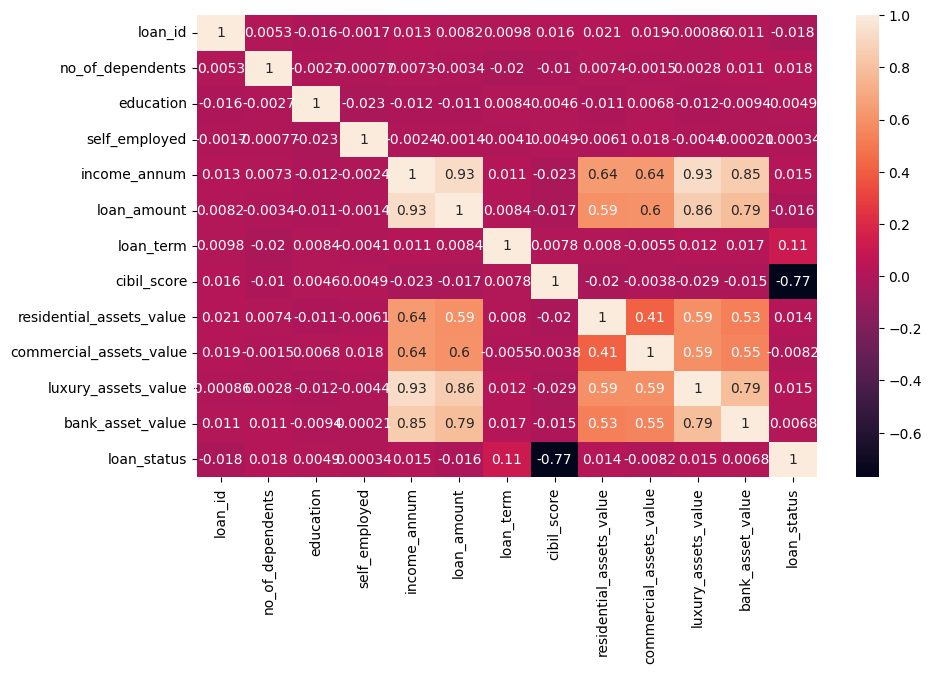

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.show()

Observation:

Applicants with higher income can get the higher loan amount

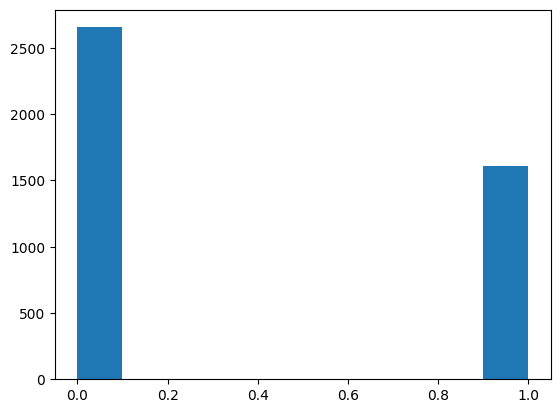

In [ ]:
plt.hist(df['loan_status'])
plt.show()

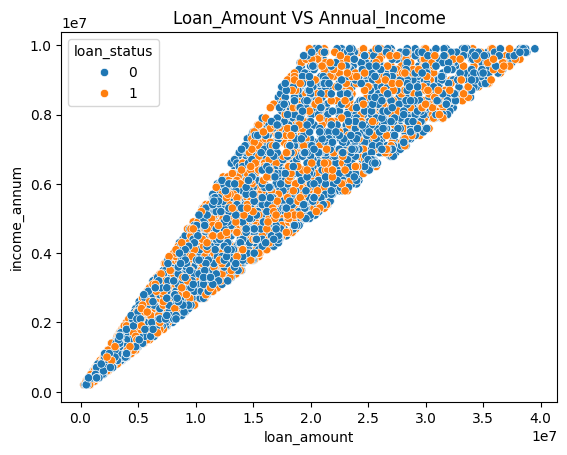

In [ ]:
sns.scatterplot(x='loan_amount',y='income_annum',hue='loan_status',data=df)
plt.title('Loan_Amount VS Annual_Income')
plt.show()

Higher the Annual Income - Higher the Loan Amount the Applicants Can Get

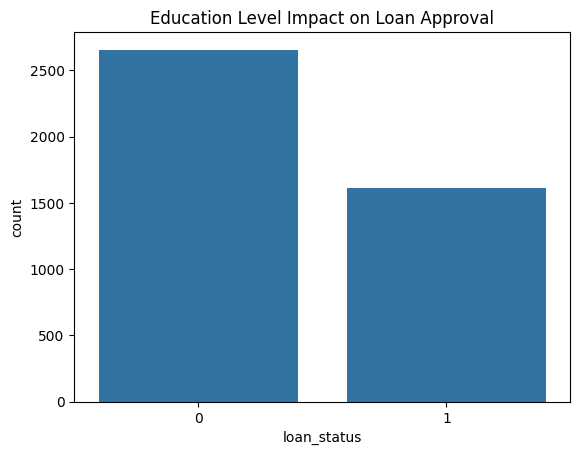

In [ ]:
sns.countplot( x='loan_status', data=df)
plt.title('Education Level Impact on Loan Approval')
plt.show()

Educated people are more likely to Get Loan

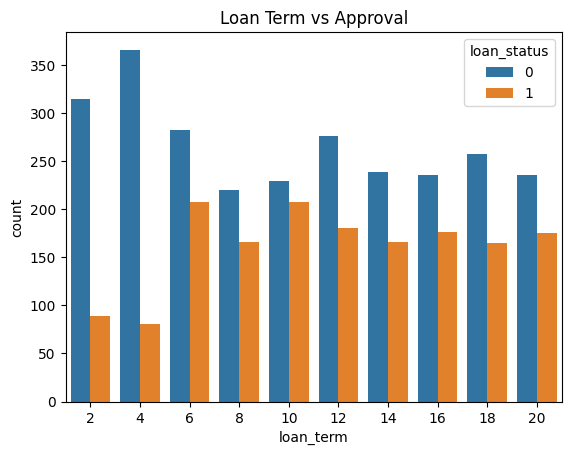

In [ ]:
sns.countplot(x='loan_term', hue='loan_status', data=df)
plt.title('Loan Term vs Approval')
plt.show()

<Axes: xlabel='loan_status', ylabel='income_annum'>

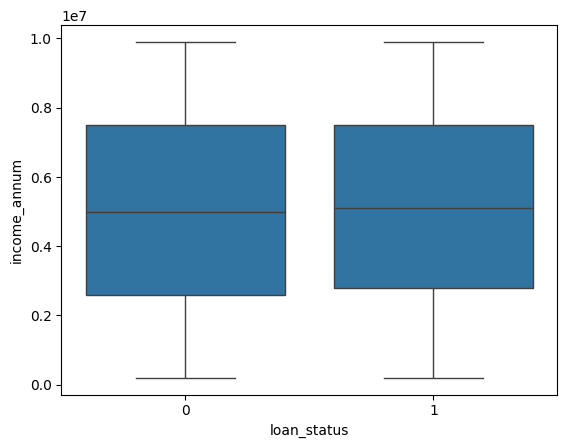

In [ ]:
sns.boxplot(x='loan_status',y='income_annum',data=df)

Training and Testing Models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
x.shape,x_train.shape,x_test.shape

((4269, 12), (3415, 12), (854, 12))

In [ ]:
model1=SVC()
model1.fit(x_train,y_train)

SVC()

In [ ]:
x_train_predict=model1.predict(x_train)
training_data_accuracy=accuracy_score(x_train_predict,y_train)

In [ ]:
print("Accuracy on SVC of Training Data:",training_data_accuracy)

Accuracy on SVC of Training Data: 0.6225475841874085


In [ ]:
x_test_predict=model1.predict(x_test)
testing_data_accuracy=accuracy_score(x_test_predict,y_test)

In [ ]:
print("Accuracy on SVC of Testing Data:",testing_data_accuracy)

Accuracy on SVC of Testing Data: 0.6206088992974239


In [ ]:
model2=RandomForestClassifier()
model2.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
x_train_prediction=model2.predict(x_train)
Training_data_accuracy=accuracy_score(x_train_prediction,y_train)

In [ ]:
print("Accuracy on Random Forest Classifier of Training Data:",Training_data_accuracy)

Accuracy on Random Forest Classifier of Training Data: 1.0


In [ ]:
x_test_prediction=model2.predict(x_test)
Testing_data_accuracy=accuracy_score(x_test_prediction,y_test)

In [ ]:
print("Accuracy on Random Forest Classifier of Testing Data:",Testing_data_accuracy)

Accuracy on Random Forest Classifier of Testing Data: 0.977751756440281


| Model               | Accuracy |
| ------------------- | -------- |
| Random Forest       | 97%      |
| svm SVC                 | 62%      |


***Prediction***


In [ ]:
input_data=x.sample()


In [ ]:
input_data_as_numpy=np.asarray(input_data)

In [ ]:
input_data_reshaped=input_data_as_numpy.reshape(1,-1)

In [ ]:
print("prediction by SVC")
prediction=model1.predict(input_data_reshaped)
print(prediction)
if prediction ==0:
  print("Approved")
else:
  print("Rejected")

prediction by SVC
[0]
Approved


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
print("prediction by Random Forest Classifier")
prediction=model2.predict(input_data_reshaped)
print(prediction)
if prediction ==0:
  print("Approved")
else:
  print("Rejected")

prediction by Random Forest Classifier
[1]
Rejected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
